In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

In [28]:
# Paths to deduped parquet files
base_dir = Path("../data/Postings")

files = [
    base_dir / "SG-2022-WITHOUT-REPOSTS-W60D.parquet",
    base_dir / "SG-2023-WITHOUT-REPOSTS-W60D.parquet",
    base_dir / "SG-2024-WITHOUT-REPOSTS-W60D.parquet",
]

# Read and concatenate
data_df = pd.concat(
    [pd.read_parquet(f) for f in files],
    ignore_index=True
)

print("Combined data_df shape:", data_df.shape)
print("Years covered:", sorted(data_df["post_date"].dt.year.unique()))

Combined data_df shape: (1492675, 41)
Years covered: [2022, 2023, 2024]


In [29]:
recruitment_industries = [
    'Recruitment and Staffing Services',
    'Employment and Staffing Services',
    'Employment and Recruitment Services',
    'Human Resources and Recruitment Services',
    'Online Employment Platforms',
    'Human Resources and Workforce Solutions',
    'Business Process Outsourcing Services'
]

In [30]:
d_unique_filtered = data_df[~data_df['rics_k400'].isin(recruitment_industries)].copy()

In [31]:
d_unique_filtered['rics_k50'].unique()

array(['Logistics and Transportation', 'Information Technology Services',
       'Marketing and Advertising Services', 'Digital Commerce Services',
       'Apparel Retail', 'Energy and Resources', 'Education Services',
       'Professional Development Services', 'IT Consulting Services',
       'Financial Services', 'Miscellaneous', 'Wellness Products',
       'Consulting and Advisory Services', 'Aerospace and Defense',
       'Humanitarian Services', 'Media and Entertainment',
       'Engineering and Construction Services', 'Food and Beverage',
       'Electronics Manufacturing', 'Hospitality and Tourism Management',
       'Industrial Manufacturing', 'Healthcare and Wellness Services',
       'Automation Solutions', 'Agricultural Services',
       'Culture and Entertainment', 'Commercial Aviation',
       'Research and Development', 'Real Estate and Development',
       'Biotech and Healthcare Services', 'Environmental Services',
       'Business Services', 'Architectural Design Serv

EDA for Industry Triple DiD

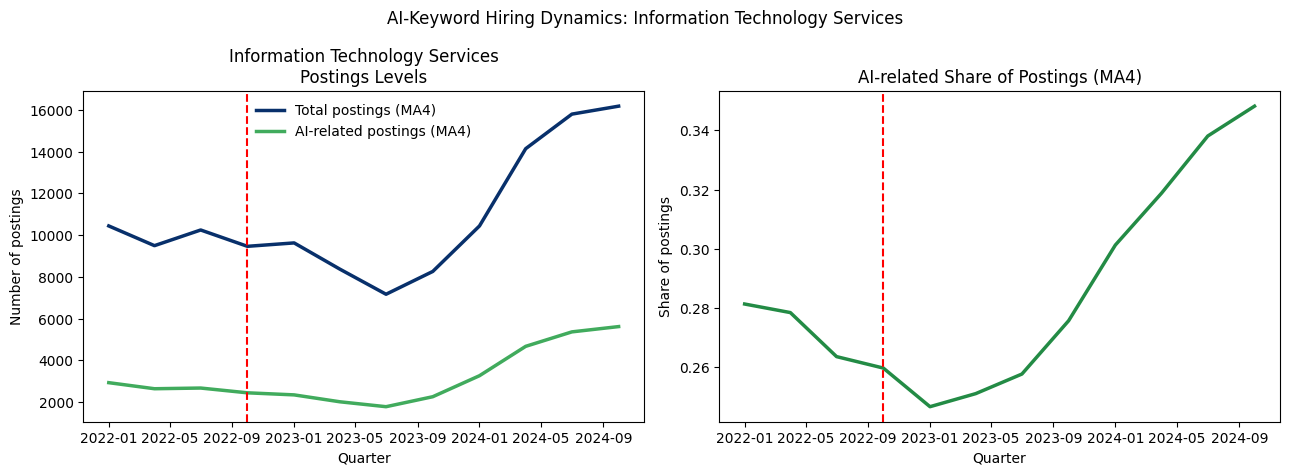

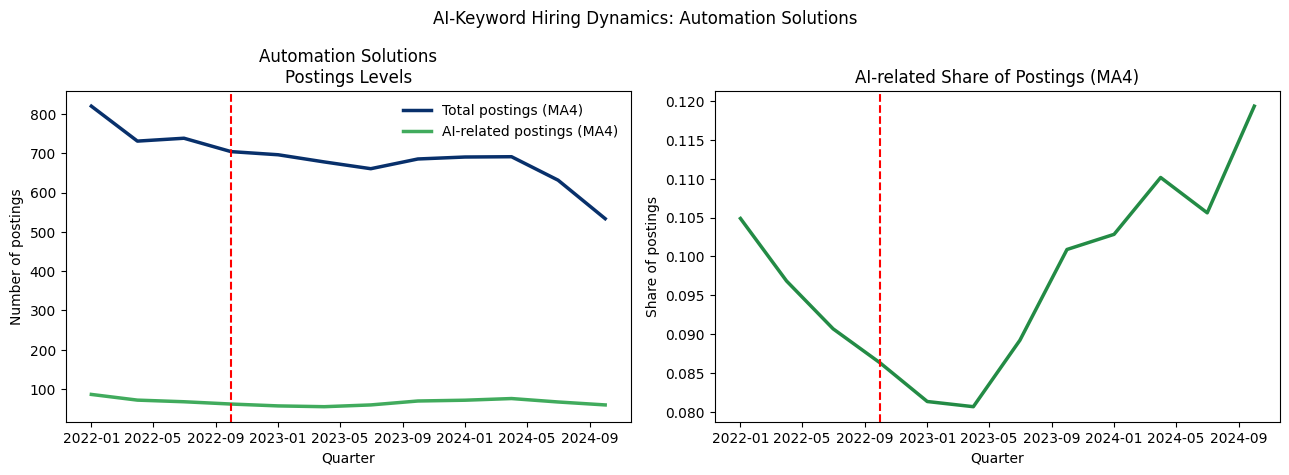

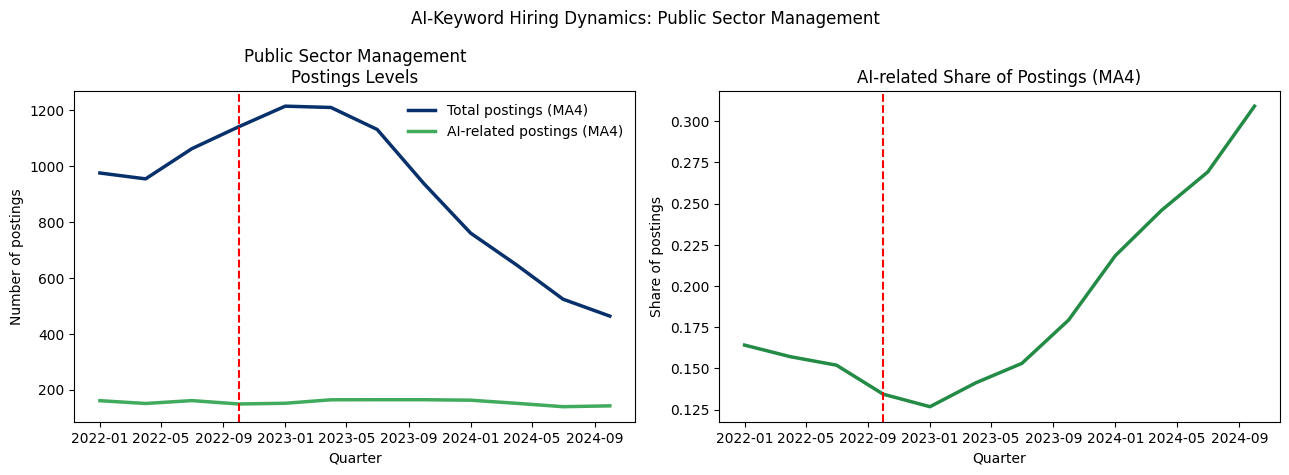

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# -----------------------------
# Settings
# -----------------------------
DATE_COL = "post_date"
IND_COL = "rics_k50"
DESC_COL = "description"

industries = [
    "Information Technology Services",
    "Automation Solutions",
    "Public Sector Management"
]

TREAT_Q = pd.Period("2022Q4", freq="Q")

# -----------------------------
# GenAI keyword pattern
# -----------------------------
keywords = [
    "copilot","claude","gemini","large language model","llm","generative ai",
    "chatgpt","gen ai","gpt","langchain","rag","retrieval-augmented generation",
    "vector embeddings","vector database","transformer-based model",
    "prompt engineering","prompt design","llamaindex","pinecone",
    "weaviate","milvus","openai api","anthropic claude api",
    "azure openai","google vertex ai","huggingface transformers","retrievalqa"
]

pattern = re.compile("|".join([re.escape(k) for k in keywords]), re.IGNORECASE)

# -----------------------------
# Clean + prepare
# -----------------------------
d = d_unique_filtered.copy()

d[DATE_COL] = pd.to_datetime(d[DATE_COL], errors="coerce")
d = d[d[DATE_COL].notna()].copy()
d["qtr"] = d[DATE_COL].dt.to_period("Q")
d["qtr_start"] = d["qtr"].dt.to_timestamp(how="start")

# AI-related indicator
d["ai_related"] = d[DESC_COL].astype(str).apply(lambda x: bool(pattern.search(x)))

# -----------------------------
# Loop industries
# -----------------------------
for ind in industries:

    di = d[d[IND_COL] == ind].copy()
    if di.empty:
        print(f"No data for {ind}")
        continue

    # Aggregate quarterly
    agg = (
        di.groupby("qtr", as_index=False)
        .agg(
            total_postings=("ai_related", "count"),
            ai_postings=("ai_related", "sum")
        )
    )

    agg["ai_share"] = agg["ai_postings"] / agg["total_postings"]
    agg["qtr_start"] = agg["qtr"].dt.to_timestamp(how="start")

    # 4-quarter moving averages (smooth volatility)
    agg["total_ma4"] = agg["total_postings"].rolling(4, min_periods=1).mean()
    agg["ai_ma4"] = agg["ai_postings"].rolling(4, min_periods=1).mean()
    agg["share_ma4"] = agg["ai_share"].rolling(4, min_periods=1).mean()

    # -----------------------------
    # Plot
    # -----------------------------
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True)

    treat_date = TREAT_Q.to_timestamp(how="start")

    # Panel 1: Levels
    axes[0].plot(agg["qtr_start"], agg["total_ma4"], label="Total postings (MA4)", linewidth=2.5, color="#08306b")
    axes[0].plot(agg["qtr_start"], agg["ai_ma4"], label="AI-related postings (MA4)", linewidth=2.5, color="#41ab5d")
    axes[0].axvline(treat_date, linestyle="--", color="red", linewidth=1.5)
    axes[0].set_title(f"{ind}\nPostings Levels")
    axes[0].set_ylabel("Number of postings")
    axes[0].legend(frameon=False)

    # Panel 2: Share
    axes[1].plot(agg["qtr_start"], agg["share_ma4"], linewidth=2.5, color="#238b45")
    axes[1].axvline(treat_date, linestyle="--", color="red", linewidth=1.5)
    axes[1].set_title("AI-related Share of Postings (MA4)")
    axes[1].set_ylabel("Share of postings")

    for ax in axes:
        ax.set_xlabel("Quarter")

    plt.suptitle(f"AI-Keyword Hiring Dynamics: {ind}", fontsize=12)
    plt.tight_layout()
    plt.show()


Triple DiD for POSITIONS (junior/senior)

In [ ]:
import os
import glob
import pandas as pd
import numpy as np

POS_DIR = r"C:\LocalOneDrive\Documents\Desktop\NUS\Y4S1\FYP\causal-impact-GenAI\data\Positions"
OCC_LEVEL_PATH = r"C:\LocalOneDrive\Documents\Desktop\NUS\Y4S1\FYP\causal-impact-GenAI\data\AI Exposure Scores\occ_level.csv"
OUT_DTA = os.path.join(POS_DIR, "occ_ind_seniority_quarter_triple_did_panel.dta")

TREAT_DATE = pd.Timestamp("2022-11-30")
DATE_COL = "startdate"
SEN_COL = "seniority"
IND_COL = "rics_k50"

pos_files = sorted(glob.glob(os.path.join(POS_DIR, "*_positions.csv")))

def _is_in_range(fn: str) -> bool:
    base = os.path.basename(fn)
    try:
        y = int(base[:4])
        q = int(base[5])
        return (y > 2022 or (y == 2022 and q >= 1)) and (y < 2024 or (y == 2024 and q <= 4))
    except Exception:
        return False

pos_files = [f for f in pos_files if _is_in_range(f)]
if len(pos_files) == 0:
    raise FileNotFoundError("No matching positions CSVs found (expect 2022Q1_positions.csv ... 2024Q4_positions.csv).")

dfs = []
for f in pos_files:
    d = pd.read_csv(f)
    d["source_file"] = os.path.basename(f)
    dfs.append(d)
positions = pd.concat(dfs, ignore_index=True)

need_cols = ["onet_code", IND_COL, DATE_COL, SEN_COL]
missing = [c for c in need_cols if c not in positions.columns]
if missing:
    raise KeyError(f"Missing required columns in positions files: {missing}")

occ = pd.read_csv(OCC_LEVEL_PATH)
positions["onet_code"] = positions["onet_code"].astype(str).str.strip()
occ["O*NET-SOC Code"] = occ["O*NET-SOC Code"].astype(str).str.strip()

occ_sub = occ[["O*NET-SOC Code", "human_rating_beta"]].rename(columns={"O*NET-SOC Code":"onet_code","human_rating_beta":"exposure"}).copy()
positions = positions.merge(occ_sub, on="onet_code", how="left")

positions[DATE_COL] = pd.to_datetime(positions[DATE_COL], errors="coerce")
positions = positions[positions[DATE_COL].notna()].copy()

positions[SEN_COL] = pd.to_numeric(positions[SEN_COL], errors="coerce")
positions = positions[positions[SEN_COL].between(1, 7, inclusive="both")].copy()

positions[IND_COL] = positions[IND_COL].astype(str).str.strip()
positions = positions[positions[IND_COL].notna() & (positions[IND_COL] != "")].copy()

positions["year"] = positions[DATE_COL].dt.year.astype(int)
positions["qtr_num"] = positions[DATE_COL].dt.quarter.astype(int)
positions["tq"] = (positions["year"] - 1960) * 4 + (positions["qtr_num"] - 1)
positions["post"] = (positions[DATE_COL] >= TREAT_DATE).astype(int)

pretreat = positions[positions[DATE_COL] < TREAT_DATE][["onet_code","exposure"]].dropna().drop_duplicates()
if pretreat.empty:
    raise ValueError("No pre-treatment rows with non-missing exposure after merge. Check onet_code formatting / exposure file.")

pre_median = float(pretreat["exposure"].median())
positions["high_exp"] = (positions["exposure"] > pre_median).astype(int)

positions["senior"] = np.where(positions[SEN_COL].between(1, 3), 0, 1)

panel = (
    positions
    .groupby(["onet_code", IND_COL, "tq", "year", "qtr_num", "senior", "high_exp"], as_index=False)
    .agg(
        postings=("onet_code", "size"),
        exposure=("exposure", "first"),
        post=("post", "max"),
    )
)

tq_2022q4 = (2022 - 1960) * 4 + (4 - 1)
panel["relq"] = panel["tq"] - tq_2022q4

panel.to_stata(OUT_DTA, write_index=False, version=118)

print("Saved:", OUT_DTA)
print("Pre-treatment median exposure used:", pre_median)
print("Panel shape:", panel.shape)
print("Missing exposure share in panel:", panel["exposure"].isna().mean())

Saved: C:\LocalOneDrive\Documents\Desktop\NUS\Y4S1\FYP\causal-impact-GenAI\data\Positions\occ_ind_seniority_quarter_triple_did_panel.dta
Pre-treatment median exposure used: 0.40625
Panel shape: (541379, 11)
Missing exposure share in panel: 0.007916819824928562


In [13]:
panel.head()

,onet_code,rics_k50,tq,year,qtr_num,senior,high_exp,postings,exposure,post,relq
0,11-1011.00,Aerospace and Defense,22,1965,3,0,0,1,0.35,0,-229
1,11-1011.00,Aerospace and Defense,31,1967,4,1,0,1,0.35,0,-220
2,11-1011.00,Aerospace and Defense,58,1974,3,0,0,1,0.35,0,-193
3,11-1011.00,Aerospace and Defense,60,1975,1,0,0,1,0.35,0,-191
4,11-1011.00,Aerospace and Defense,69,1977,2,0,0,1,0.35,0,-182


From 2015-01-01 onwards to 2024-12-31

In [15]:
import os
import glob
import pandas as pd
import numpy as np

POS_DIR = r"C:\LocalOneDrive\Documents\Desktop\NUS\Y4S1\FYP\causal-impact-GenAI\data\Positions"
OCC_LEVEL_PATH = r"C:\LocalOneDrive\Documents\Desktop\NUS\Y4S1\FYP\causal-impact-GenAI\data\AI Exposure Scores\occ_level.csv"
OUT_DTA = os.path.join(POS_DIR, "occ_ind_junior_quarter_triple_did_panel_2015_onwards.dta")

TREAT_DATE = pd.Timestamp("2022-11-30")
DATE_COL = "startdate"
SEN_COL = "seniority"
IND_COL = "rics_k50"

# Choose a window (paper uses 2015+; you can tighten if desired)
PANEL_START = pd.Timestamp("2015-01-01")
PANEL_END = pd.Timestamp("2024-12-31")

pos_files = sorted(glob.glob(os.path.join(POS_DIR, "*_positions.csv")))

def _is_in_range(fn: str) -> bool:
    base = os.path.basename(fn)
    try:
        y = int(base[:4])
        q = int(base[5])
        # Changed to start from 2015 instead of 2022
        return (y >= 2015) and (y < 2024 or (y == 2024 and q <= 4))
    except Exception:
        return False

pos_files = [f for f in pos_files if _is_in_range(f)]
if len(pos_files) == 0:
    raise FileNotFoundError("No matching positions CSVs found (expect 2015Q1_positions.csv onwards).")

dfs = []
for f in pos_files:
    d = pd.read_csv(f)
    d["source_file"] = os.path.basename(f)
    dfs.append(d)
positions = pd.concat(dfs, ignore_index=True)

need_cols = ["onet_code", IND_COL, DATE_COL, SEN_COL]
missing = [c for c in need_cols if c not in positions.columns]
if missing:
    raise KeyError(f"Missing required columns in positions files: {missing}")

occ = pd.read_csv(OCC_LEVEL_PATH)
positions["onet_code"] = positions["onet_code"].astype(str).str.strip()
occ["O*NET-SOC Code"] = occ["O*NET-SOC Code"].astype(str).str.strip()

occ_sub = occ[["O*NET-SOC Code", "human_rating_beta"]].rename(columns={"O*NET-SOC Code":"onet_code","human_rating_beta":"exposure"}).copy()
positions = positions.merge(occ_sub, on="onet_code", how="left")

positions[DATE_COL] = pd.to_datetime(positions[DATE_COL], errors="coerce")
positions = positions[positions[DATE_COL].notna()].copy()

# Trim window (prevents ancient starts from contaminating anything if you ever expand input)
positions = positions[(positions[DATE_COL] >= PANEL_START) & (positions[DATE_COL] <= PANEL_END)].copy()

positions[SEN_COL] = pd.to_numeric(positions[SEN_COL], errors="coerce")
positions = positions[positions[SEN_COL].between(1, 7, inclusive="both")].copy()

positions[IND_COL] = positions[IND_COL].astype(str).str.strip()
positions = positions[positions[IND_COL].notna() & (positions[IND_COL] != "")].copy()

positions["year"] = positions[DATE_COL].dt.year.astype(int)
positions["qtr_num"] = positions[DATE_COL].dt.quarter.astype(int)
positions["tq"] = (positions["year"] - 1960) * 4 + (positions["qtr_num"] - 1)
positions["post"] = (positions[DATE_COL] >= TREAT_DATE).astype(int)

pretreat = positions[positions[DATE_COL] < TREAT_DATE][["onet_code","exposure"]].dropna().drop_duplicates()
if pretreat.empty:
    raise ValueError("No pre-treatment rows with non-missing exposure after merge. Check onet_code formatting / exposure file.")

pre_median = float(pretreat["exposure"].median())
positions["high_exp"] = (positions["exposure"] > pre_median).astype(int)

# Junior indicator: 1 for (1,2,3), 0 for (4,5,6,7)
positions["junior"] = np.where(positions[SEN_COL].between(1, 3), 1, 0)

panel = (
    positions
    .groupby(["onet_code", IND_COL, "tq", "year", "qtr_num", "junior", "high_exp"], as_index=False)
    .agg(
        postings=("onet_code", "size"),
        exposure=("exposure", "first"),
        post=("post", "max"),
    )
)

tq_2022q4 = (2022 - 1960) * 4 + (4 - 1)
panel["relq"] = panel["tq"] - tq_2022q4

panel.to_stata(OUT_DTA, write_index=False, version=118)

print("Saved:", OUT_DTA)
print("Pre-treatment median exposure used:", pre_median)
print("Panel shape:", panel.shape)
print("Missing exposure share in panel:", panel["exposure"].isna().mean())

Saved: C:\LocalOneDrive\Documents\Desktop\NUS\Y4S1\FYP\causal-impact-GenAI\data\Positions\occ_ind_junior_quarter_triple_did_panel_2015_onwards.dta
Pre-treatment median exposure used: 0.40625
Panel shape: (374727, 11)
Missing exposure share in panel: 0.005414608501655872


From 2015 onwards to 2025Q2 WITH internships

In [48]:
import os
import glob
import pandas as pd
import numpy as np

POS_DIR = r"C:\LocalOneDrive\Documents\Desktop\NUS\Y4S1\FYP\causal-impact-GenAI\data\Positions"
OCC_LEVEL_PATH = r"C:\LocalOneDrive\Documents\Desktop\NUS\Y4S1\FYP\causal-impact-GenAI\data\AI Exposure Scores\occ_level.csv"
OUT_DTA = os.path.join(POS_DIR, "occ_ind_junior_quarter_triple_did_panel_2015_onwards_with_2025.dta")

TREAT_DATE = pd.Timestamp("2022-11-30")
DATE_COL = "startdate"
SEN_COL = "seniority"
IND_COL = "rics_k50"

# Extended window to include 2025Q1 and 2025Q2
PANEL_START = pd.Timestamp("2015-01-01")
PANEL_END = pd.Timestamp("2025-06-30")

pos_files = sorted(glob.glob(os.path.join(POS_DIR, "*_positions.csv")))

def _is_in_range(fn: str) -> bool:
    base = os.path.basename(fn)
    try:
        # Handle YYYYQX_positions.csv format
        if base[4] == 'Q':
            y = int(base[:4])
            q = int(base[5])
            return (y >= 2015) and (y < 2025 or (y == 2025 and q <= 2))
        # Handle YYYY_positions.csv format (like 2025_positions.csv)
        elif base[4] == '_':
            y = int(base[:4])
            return y >= 2015 and y <= 2025
        else:
            return False
    except Exception:
        return False

pos_files = [f for f in pos_files if _is_in_range(f)]
if len(pos_files) == 0:
    raise FileNotFoundError("No matching positions CSVs found (expect 2015Q1_positions.csv onwards or YYYY_positions.csv).")

print(f"Loading {len(pos_files)} position files:")
for f in pos_files:
    print(f"  - {os.path.basename(f)}")

dfs = []
for f in pos_files:
    d = pd.read_csv(f)
    d["source_file"] = os.path.basename(f)
    dfs.append(d)
positions = pd.concat(dfs, ignore_index=True)

need_cols = ["onet_code", IND_COL, DATE_COL, SEN_COL]
missing = [c for c in need_cols if c not in positions.columns]
if missing:
    raise KeyError(f"Missing required columns in positions files: {missing}")

occ = pd.read_csv(OCC_LEVEL_PATH)
positions["onet_code"] = positions["onet_code"].astype(str).str.strip()
occ["O*NET-SOC Code"] = occ["O*NET-SOC Code"].astype(str).str.strip()

occ_sub = occ[["O*NET-SOC Code", "human_rating_beta"]].rename(columns={"O*NET-SOC Code":"onet_code","human_rating_beta":"exposure"}).copy()
positions = positions.merge(occ_sub, on="onet_code", how="left")

positions[DATE_COL] = pd.to_datetime(positions[DATE_COL], errors="coerce")
positions = positions[positions[DATE_COL].notna()].copy()

# Trim window (prevents ancient starts from contaminating anything if you ever expand input)
positions = positions[(positions[DATE_COL] >= PANEL_START) & (positions[DATE_COL] <= PANEL_END)].copy()

print(f"\nDate range in final positions: {positions[DATE_COL].min()} to {positions[DATE_COL].max()}")

positions[SEN_COL] = pd.to_numeric(positions[SEN_COL], errors="coerce")
positions = positions[positions[SEN_COL].between(1, 7, inclusive="both")].copy()

positions[IND_COL] = positions[IND_COL].astype(str).str.strip()
positions = positions[positions[IND_COL].notna() & (positions[IND_COL] != "")].copy()

positions["year"] = positions[DATE_COL].dt.year.astype(int)
positions["qtr_num"] = positions[DATE_COL].dt.quarter.astype(int)
positions["tq"] = (positions["year"] - 1960) * 4 + (positions["qtr_num"] - 1)
positions["post"] = (positions[DATE_COL] >= TREAT_DATE).astype(int)

pretreat = positions[positions[DATE_COL] < TREAT_DATE][["onet_code","exposure"]].dropna().drop_duplicates()
if pretreat.empty:
    raise ValueError("No pre-treatment rows with non-missing exposure after merge. Check onet_code formatting / exposure file.")

pre_median = float(pretreat["exposure"].median())
positions["high_exp"] = (positions["exposure"] > pre_median).astype(int)

# Junior indicator: 1 for (1,2,3), 0 for (4,5,6,7)
positions["junior"] = np.where(positions[SEN_COL].between(1, 3), 1, 0)

panel = (
    positions
    .groupby(["onet_code", IND_COL, "tq", "year", "qtr_num", "junior", "high_exp"], as_index=False)
    .agg(
        postings=("onet_code", "size"),
        exposure=("exposure", "first"),
        post=("post", "max"),
    )
)

tq_2022q4 = (2022 - 1960) * 4 + (4 - 1)
panel["relq"] = panel["tq"] - tq_2022q4

# Verify we have 2025 data
quarters_2025 = panel[panel["year"] == 2025]["qtr_num"].unique()
print(f"\n2025 quarters in panel: {sorted(quarters_2025)}")
print(f"relq range: {panel['relq'].min()} to {panel['relq'].max()}")

panel.to_stata(OUT_DTA, write_index=False, version=118)

print("\nSaved:", OUT_DTA)
print("Pre-treatment median exposure used:", pre_median)
print("Panel shape:", panel.shape)
print("Missing exposure share in panel:", panel["exposure"].isna().mean())

Loading 13 position files:
  - 2022Q1_positions.csv
  - 2022Q2_positions.csv
  - 2022Q3_positions.csv
  - 2022Q4_positions.csv
  - 2023Q1_positions.csv
  - 2023Q2_positions.csv
  - 2023Q3_positions.csv
  - 2023Q4_positions.csv
  - 2024Q1_positions.csv
  - 2024Q2_positions.csv
  - 2024Q3_positions.csv
  - 2024Q4_positions.csv
  - 2025_positions.csv

Date range in final positions: 2015-01-01 00:00:00 to 2025-06-01 00:00:00

2025 quarters in panel: [1, 2]
relq range: -31 to 10

Saved: C:\LocalOneDrive\Documents\Desktop\NUS\Y4S1\FYP\causal-impact-GenAI\data\Positions\occ_ind_junior_quarter_triple_did_panel_2015_onwards_with_2025.dta
Pre-treatment median exposure used: 0.40625
Panel shape: (390152, 11)
Missing exposure share in panel: 0.005428653447886978


Filtering out INTERNSHIPS before saving panel

In [47]:
import os
import glob
import re
import csv
import sys
import pandas as pd
import numpy as np

POS_DIR = r"C:\LocalOneDrive\Documents\Desktop\NUS\Y4S1\FYP\causal-impact-GenAI\data\Positions"
OCC_LEVEL_PATH = r"C:\LocalOneDrive\Documents\Desktop\NUS\Y4S1\FYP\causal-impact-GenAI\data\AI Exposure Scores\occ_level.csv"
OUT_DTA = os.path.join(POS_DIR, "occ_ind_junior_quarter_triple_did_panel_2015_onwards_no_intern.dta")

TITLES_DIR = r"C:\LocalOneDrive\Documents\Desktop\NUS\Y4S1\FYP\causal-impact-GenAI\data\Positions\Titles"
TITLES_FILES = [os.path.join(TITLES_DIR, "titles.csv"), os.path.join(TITLES_DIR, "titles_2025.csv")]

TREAT_DATE = pd.Timestamp("2022-11-30")
DATE_COL = "startdate"
SEN_COL = "seniority"
IND_COL = "rics_k50"

PANEL_START = pd.Timestamp("2015-01-01")
PANEL_END = pd.Timestamp("2025-06-30")

def read_titles_robust(path: str) -> pd.DataFrame:
    try:
        csv.field_size_limit(min(sys.maxsize, 2_000_000_000))
    except Exception:
        pass
    encodings_to_try = ["utf-8", "utf-8-sig", "cp1252", "latin1"]
    last_err = None
    for enc in encodings_to_try:
        try:
            return pd.read_csv(
                path,
                engine="python",
                encoding=enc,
                encoding_errors="replace",
                on_bad_lines="skip",
                quotechar='"',
                escapechar="\\",
            )
        except Exception as e:
            last_err = e
    raise last_err

# -----------------------------
# Load + merge titles (user_id -> title_raw), then filter internships
# -----------------------------
titles_parts = []
for fp in TITLES_FILES:
    if os.path.exists(fp):
        t = read_titles_robust(fp)
        titles_parts.append(t)
    else:
        print(f"[WARN] Missing titles file: {fp}")

if len(titles_parts) == 0:
    raise FileNotFoundError("No titles.csv / titles_2025.csv found in Titles folder.")

titles = pd.concat(titles_parts, ignore_index=True)

if "user_id" not in titles.columns or "title_raw" not in titles.columns:
    raise KeyError("Titles files must contain 'user_id' and 'title_raw' columns.")

titles["user_id"] = pd.to_numeric(titles["user_id"], errors="coerce")
titles = titles.dropna(subset=["user_id"]).copy()
titles["user_id"] = titles["user_id"].astype("int64")

titles["title_raw"] = titles["title_raw"].astype(str)

# De-dupe titles to 1 row per user_id (keep longest title as heuristic)
titles["title_len"] = titles["title_raw"].str.len()
titles = titles.sort_values(["user_id", "title_len"], ascending=[True, False]).drop_duplicates(subset=["user_id"])
titles = titles.drop(columns=["title_len"])

# -----------------------------
# Read positions files (2015Q1 onwards through 2025Q2)
# -----------------------------
pos_files = sorted(glob.glob(os.path.join(POS_DIR, "*_positions.csv")))

def _is_in_range(fn: str) -> bool:
    base = os.path.basename(fn)
    try:
        # Handle YYYYQX_positions.csv format
        if base[4] == 'Q':
            y = int(base[:4])
            q = int(base[5])
            return (y >= 2015) and (y < 2025 or (y == 2025 and q <= 2))
        # Handle YYYY_positions.csv format (like 2025_positions.csv)
        elif base[4] == '_':
            y = int(base[:4])
            return y >= 2015 and y <= 2025
        else:
            return False
    except Exception:
        return False

pos_files = [f for f in pos_files if _is_in_range(f)]
if len(pos_files) == 0:
    raise FileNotFoundError("No matching positions CSVs found (expect 2015Q1_positions.csv onwards or YYYY_positions.csv).")

print(f"Loading {len(pos_files)} position files:")
for f in pos_files:
    print(f"  - {os.path.basename(f)}")

dfs = []
for f in pos_files:
    d = pd.read_csv(f)
    d["source_file"] = os.path.basename(f)
    dfs.append(d)
positions = pd.concat(dfs, ignore_index=True)

need_cols = ["user_id", "onet_code", IND_COL, DATE_COL, SEN_COL]
missing = [c for c in need_cols if c not in positions.columns]
if missing:
    raise KeyError(f"Missing required columns in positions files: {missing}")

positions["user_id"] = pd.to_numeric(positions["user_id"], errors="coerce")
positions = positions.dropna(subset=["user_id"]).copy()
positions["user_id"] = positions["user_id"].astype("int64")

# Join titles -> filter internship / intern
positions = positions.merge(titles[["user_id", "title_raw"]], on="user_id", how="left")

# Count intern positions BEFORE filtering
intern_pat = r"\b(intern|internship)\b"
has_intern = positions["title_raw"].fillna("").str.contains(intern_pat, case=False, regex=True)
n_intern_before = has_intern.sum()
n_total_before = len(positions)

# Now filter out interns
positions = positions[~has_intern].copy()
n_after = len(positions)

print(f"\nDropped {n_intern_before:,} internship positions out of {n_total_before:,} total ({100*n_intern_before/n_total_before:.2f}%)")
print(f"Remaining positions: {n_after:,}")

# -----------------------------
# Merge exposure
# -----------------------------
occ = pd.read_csv(OCC_LEVEL_PATH)
positions["onet_code"] = positions["onet_code"].astype(str).str.strip()
occ["O*NET-SOC Code"] = occ["O*NET-SOC Code"].astype(str).str.strip()

occ_sub = occ[["O*NET-SOC Code", "human_rating_beta"]].rename(columns={"O*NET-SOC Code":"onet_code","human_rating_beta":"exposure"}).copy()
positions = positions.merge(occ_sub, on="onet_code", how="left")

# -----------------------------
# Clean + time vars
# -----------------------------
positions[DATE_COL] = pd.to_datetime(positions[DATE_COL], errors="coerce")
positions = positions[positions[DATE_COL].notna()].copy()
positions = positions[(positions[DATE_COL] >= PANEL_START) & (positions[DATE_COL] <= PANEL_END)].copy()

print(f"\nDate range in final positions: {positions[DATE_COL].min()} to {positions[DATE_COL].max()}")

positions[SEN_COL] = pd.to_numeric(positions[SEN_COL], errors="coerce")
positions = positions[positions[SEN_COL].between(1, 7, inclusive="both")].copy()

positions[IND_COL] = positions[IND_COL].astype(str).str.strip()
positions = positions[positions[IND_COL].notna() & (positions[IND_COL] != "")].copy()

positions["year"] = positions[DATE_COL].dt.year.astype(int)
positions["qtr_num"] = positions[DATE_COL].dt.quarter.astype(int)
positions["tq"] = (positions["year"] - 1960) * 4 + (positions["qtr_num"] - 1)
positions["post"] = (positions[DATE_COL] >= TREAT_DATE).astype(int)

pretreat = positions[positions[DATE_COL] < TREAT_DATE][["onet_code","exposure"]].dropna().drop_duplicates()
if pretreat.empty:
    raise ValueError("No pre-treatment rows with non-missing exposure after merge. Check onet_code formatting / exposure file.")
pre_median = float(pretreat["exposure"].median())
positions["high_exp"] = (positions["exposure"] > pre_median).astype(int)

# Junior indicator
positions["junior"] = np.where(positions[SEN_COL].between(1, 3), 1, 0)

# -----------------------------
# Aggregate panel
# -----------------------------
panel = (
    positions
    .groupby(["onet_code", IND_COL, "tq", "year", "qtr_num", "junior", "high_exp"], as_index=False)
    .agg(
        postings=("onet_code", "size"),
        exposure=("exposure", "first"),
        post=("post", "max"),
    )
)

tq_2022q4 = (2022 - 1960) * 4 + (4 - 1)
panel["relq"] = panel["tq"] - tq_2022q4

# Verify we have 2025 data
quarters_2025 = panel[panel["year"] == 2025]["qtr_num"].unique()
print(f"\n2025 quarters in panel: {sorted(quarters_2025)}")
print(f"relq range: {panel['relq'].min()} to {panel['relq'].max()}")

# Show quarter distribution
print("\nQuarter distribution:")
qtr_counts = panel.groupby(["year", "qtr_num"]).size().reset_index(name="count")
print(qtr_counts.tail(10))

panel.to_stata(OUT_DTA, write_index=False, version=118)

print("\nSaved:", OUT_DTA)
print("Pre-treatment median exposure used:", pre_median)
print("Panel shape:", panel.shape)
print("Missing exposure share in panel:", panel["exposure"].isna().mean())

Loading 13 position files:
  - 2022Q1_positions.csv
  - 2022Q2_positions.csv
  - 2022Q3_positions.csv
  - 2022Q4_positions.csv
  - 2023Q1_positions.csv
  - 2023Q2_positions.csv
  - 2023Q3_positions.csv
  - 2023Q4_positions.csv
  - 2024Q1_positions.csv
  - 2024Q2_positions.csv
  - 2024Q3_positions.csv
  - 2024Q4_positions.csv
  - 2025_positions.csv


C:\Users\teomi\AppData\Local\Temp\ipykernel_38004\427343199.py:127: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  has_intern = positions["title_raw"].fillna("").str.contains(intern_pat, case=False, regex=True)



Dropped 154,970 internship positions out of 3,095,883 total (5.01%)
Remaining positions: 2,940,913

Date range in final positions: 2015-01-01 00:00:00 to 2025-06-01 00:00:00

2025 quarters in panel: [1, 2]
relq range: -31 to 10

Quarter distribution:
    year  qtr_num  count
32  2023        1  13582
33  2023        2  12884
34  2023        3  12871
35  2023        4  11021
36  2024        1  12460
37  2024        2  12032
38  2024        3  11735
39  2024        4   9352
40  2025        1   9308
41  2025        2   5438

Saved: C:\LocalOneDrive\Documents\Desktop\NUS\Y4S1\FYP\causal-impact-GenAI\data\Positions\occ_ind_junior_quarter_triple_did_panel_2015_onwards_no_intern.dta
Pre-treatment median exposure used: 0.40625
Panel shape: (384483, 11)
Missing exposure share in panel: 0.005472283560001352


EDA for POSITIONS (2015 onwards)

C:\Users\teomi\AppData\Local\Temp\ipykernel_38004\91313213.py:92: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("Blues")


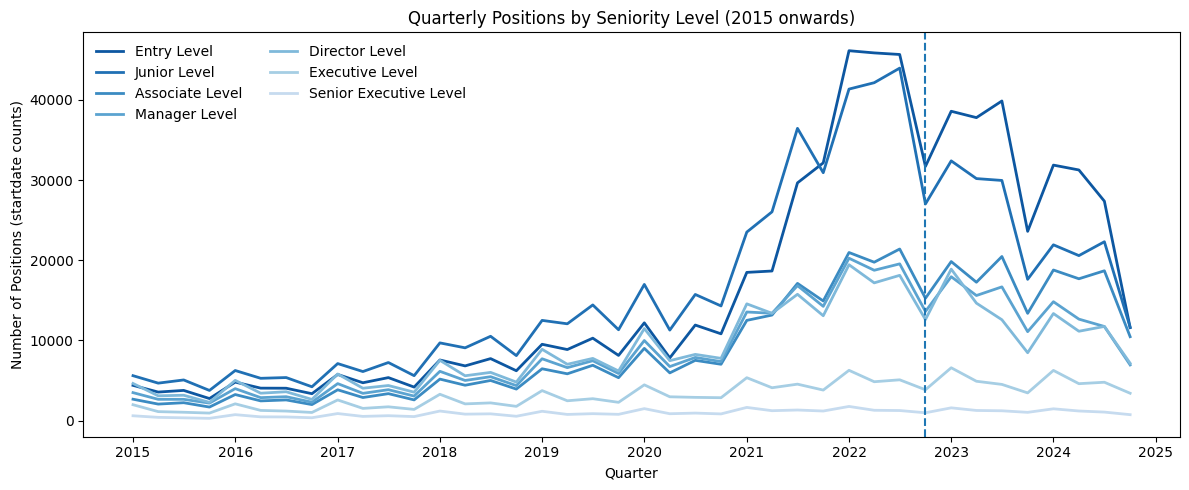

In [18]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap

# -----------------------------
# Paths (same as yours)
# -----------------------------
POS_DIR = r"C:\LocalOneDrive\Documents\Desktop\NUS\Y4S1\FYP\causal-impact-GenAI\data\Positions"

# Treatment quarter marker (ChatGPT release is 2022-11-30 -> 2022Q4)
TREAT_Q = pd.Period("2022Q4", freq="Q")
PANEL_START = pd.Timestamp("2015-01-01")

DATE_COL = "startdate"
SEN_COL = "seniority"

# Seniority labels (1..7)
SEN_LABELS = {
    1: "Entry Level",
    2: "Junior Level",
    3: "Associate Level",
    4: "Manager Level",
    5: "Director Level",
    6: "Executive Level",
    7: "Senior Executive Level",
}

# -----------------------------
# 1) Read all *_positions.csv
# -----------------------------
pos_files = sorted(glob.glob(os.path.join(POS_DIR, "*_positions.csv")))
if len(pos_files) == 0:
    raise FileNotFoundError(f"No *_positions.csv found in {POS_DIR}")

dfs = []
for f in pos_files:
    d = pd.read_csv(f)
    d["source_file"] = os.path.basename(f)
    dfs.append(d)

positions = pd.concat(dfs, ignore_index=True)

# -----------------------------
# 2) Cleaning + restrict to 2015 onwards
# -----------------------------
if DATE_COL not in positions.columns:
    raise KeyError(f"Expected date column '{DATE_COL}' not found in positions files.")
if SEN_COL not in positions.columns:
    raise KeyError(f"Expected seniority column '{SEN_COL}' not found in positions files.")

positions[DATE_COL] = pd.to_datetime(positions[DATE_COL], errors="coerce")
positions = positions[positions[DATE_COL].notna()].copy()
positions = positions[positions[DATE_COL] >= PANEL_START].copy()

positions[SEN_COL] = pd.to_numeric(positions[SEN_COL], errors="coerce")
positions = positions[positions[SEN_COL].between(1, 7, inclusive="both")].copy()
positions[SEN_COL] = positions[SEN_COL].astype(int)

positions["qtr"] = positions[DATE_COL].dt.to_period("Q")

# -----------------------------
# 3) Aggregate: postings per quarter per seniority
# -----------------------------
ts = (
    positions
    .groupby(["qtr", SEN_COL], as_index=False)
    .size()
    .rename(columns={"size": "postings"})
)

all_qtrs = pd.period_range(ts["qtr"].min(), ts["qtr"].max(), freq="Q")
all_sen = pd.Index(range(1, 8), name=SEN_COL)

full = (
    pd.MultiIndex.from_product([all_qtrs, all_sen], names=["qtr", SEN_COL])
    .to_frame(index=False)
    .merge(ts, on=["qtr", SEN_COL], how="left")
)

full["postings"] = full["postings"].fillna(0)
full["qtr_start"] = full["qtr"].dt.to_timestamp(how="start")

# -----------------------------
# 4) Plot with single-hue shades (darkest = most junior)
# -----------------------------
plt.figure(figsize=(12, 5))

# Use a single-hue colormap; "Blues" works well. Darker for lower seniority.
cmap = get_cmap("Blues")

# Map 1..7 to darker->lighter (junior darkest)
# Use values in [0.85 .. 0.25] so none are too faint.
shade_vals = np.linspace(0.85, 0.25, 7)

for idx, s in enumerate(range(1, 8)):
    d = full[full[SEN_COL] == s].sort_values("qtr_start")
    color = cmap(shade_vals[idx])
    plt.plot(d["qtr_start"], d["postings"], label=SEN_LABELS[s], color=color, linewidth=2)

# Treatment line
treat_date = TREAT_Q.to_timestamp(how="start")
plt.axvline(treat_date, linestyle="--", linewidth=1.5)
plt.text(treat_date, plt.ylim()[1] * 0.95, "", rotation=90, va="top", ha="right")

plt.title("Quarterly Positions by Seniority Level (2015 onwards)")
plt.xlabel("Quarter")
plt.ylabel("Number of Positions (startdate counts)")
plt.legend(ncol=2, frameon=False)
plt.tight_layout()
plt.show()

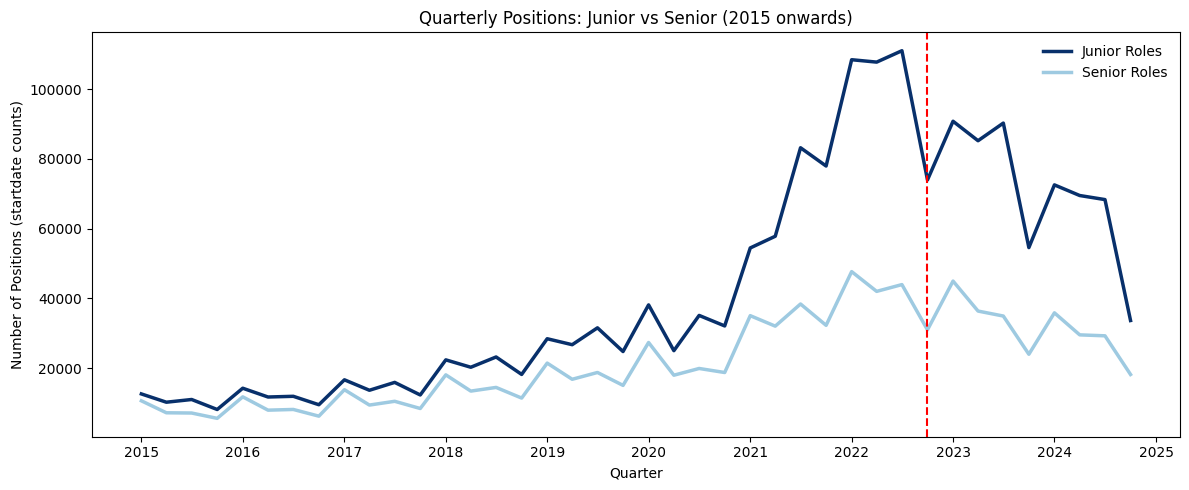

In [20]:
# -----------------------------
# 5) Group into Junior (1-3) vs Senior (4-7)
# -----------------------------

# Create group label
full["group"] = np.where(full[SEN_COL].isin([1,2,3]), "Junior Roles", "Senior Roles")

# Aggregate by quarter and group
grouped = (
    full
    .groupby(["qtr", "qtr_start", "group"], as_index=False)["postings"]
    .sum()
)

# -----------------------------
# 6) Plot grouped lines
# -----------------------------

plt.figure(figsize=(12, 5))

# Use a clear two-color contrast
junior_color = "#08306b"   # Dark blue
senior_color = "#9ecae1"   # Light blue

for g, color in zip(["Junior Roles", "Senior Roles"], [junior_color, senior_color]):
    d = grouped[grouped["group"] == g].sort_values("qtr_start")
    plt.plot(d["qtr_start"], d["postings"], label=g, color=color, linewidth=2.5)

# Treatment line
treat_date = TREAT_Q.to_timestamp(how="start")
plt.axvline(treat_date, linestyle="--", linewidth=1.5, color="red")
plt.text(treat_date, plt.ylim()[1]*0.95, "", rotation=90, va="top")

plt.title("Quarterly Positions: Junior vs Senior (2015 onwards)")
plt.xlabel("Quarter")
plt.ylabel("Number of Positions (startdate counts)")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


C:\Users\teomi\AppData\Local\Temp\ipykernel_38004\386076811.py:87: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  junior_cmap = get_cmap("Blues")
C:\Users\teomi\AppData\Local\Temp\ipykernel_38004\386076811.py:88: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  senior_cmap = get_cmap("Greens")


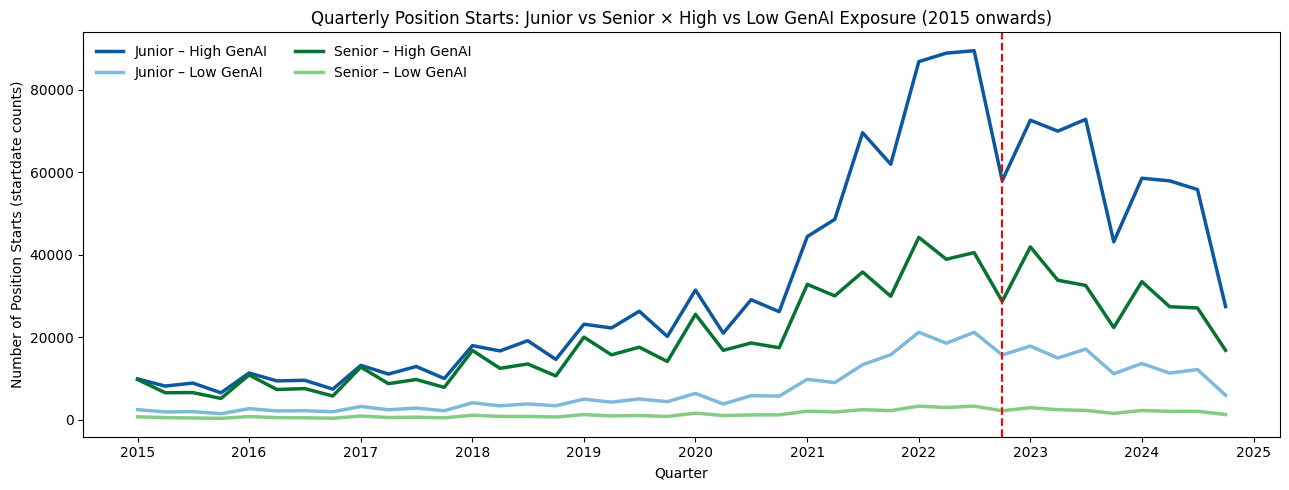

In [26]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

POS_DIR = r"C:\LocalOneDrive\Documents\Desktop\NUS\Y4S1\FYP\causal-impact-GenAI\data\Positions"
OCC_EXPOSURE_PATH = r"C:\LocalOneDrive\Documents\Desktop\NUS\Y4S1\FYP\causal-impact-GenAI\data\AI Exposure Scores\occ_level.csv"
EXPOSURE_COL = "human_rating_beta"
ONET_OCC_COL = "O*NET-SOC Code"
ONET_POS_COL = "onet_code"

TREAT_Q = pd.Period("2022Q4", freq="Q")
PANEL_START = pd.Timestamp("2015-01-01")
DATE_COL = "startdate"
SEN_COL = "seniority"

pos_files = sorted(glob.glob(os.path.join(POS_DIR, "*_positions.csv")))
if len(pos_files) == 0:
    raise FileNotFoundError(f"No *_positions.csv found in {POS_DIR}")

dfs = []
for f in pos_files:
    d = pd.read_csv(f)
    d["source_file"] = os.path.basename(f)
    dfs.append(d)
positions = pd.concat(dfs, ignore_index=True)

positions[DATE_COL] = pd.to_datetime(positions[DATE_COL], errors="coerce")
positions = positions[positions[DATE_COL].notna()].copy()
positions = positions[positions[DATE_COL] >= PANEL_START].copy()

positions[SEN_COL] = pd.to_numeric(positions[SEN_COL], errors="coerce")
positions = positions[positions[SEN_COL].between(1, 7, inclusive="both")].copy()
positions[SEN_COL] = positions[SEN_COL].astype(int)

positions[ONET_POS_COL] = positions[ONET_POS_COL].astype(str).str.strip()
positions["qtr"] = positions[DATE_COL].dt.to_period("Q")
positions["qtr_start"] = positions["qtr"].dt.to_timestamp(how="start")

# Junior vs Senior grouping
positions["sen_group"] = np.where(positions[SEN_COL].isin([1, 2, 3]), "Junior", "Senior")

# -----------------------------
# Attach high/low GenAI exposure by O*NET code (median split, pre/post invariant)
# -----------------------------
occ = pd.read_csv(OCC_EXPOSURE_PATH)
occ[ONET_OCC_COL] = occ[ONET_OCC_COL].astype(str).str.strip()
occ = occ[[ONET_OCC_COL, EXPOSURE_COL]].dropna().drop_duplicates()

median_exposure = float(occ[EXPOSURE_COL].median())
occ["treated"] = (occ[EXPOSURE_COL] > median_exposure).astype(int)
occ = occ.rename(columns={ONET_OCC_COL: ONET_POS_COL})

positions = positions.merge(occ[[ONET_POS_COL, "treated"]], on=ONET_POS_COL, how="inner")
positions["exp_group"] = np.where(positions["treated"] == 1, "High GenAI", "Low GenAI")

# -----------------------------
# Aggregate: STARTS per quarter (this is hires/starts, not employment stock)
# -----------------------------
agg = (
    positions
    .groupby(["qtr", "qtr_start", "sen_group", "exp_group"], as_index=False)
    .size()
    .rename(columns={"size": "starts"})
)

# Balance panel for the 4 lines
all_qtrs = pd.period_range(agg["qtr"].min(), agg["qtr"].max(), freq="Q")
grid = pd.MultiIndex.from_product(
    [all_qtrs, ["Junior", "Senior"], ["High GenAI", "Low GenAI"]],
    names=["qtr", "sen_group", "exp_group"]
).to_frame(index=False)
grid["qtr_start"] = grid["qtr"].dt.to_timestamp(how="start")

agg = grid.merge(agg, on=["qtr", "qtr_start", "sen_group", "exp_group"], how="left")
agg["starts"] = agg["starts"].fillna(0)

# -----------------------------
# Plot 4 lines (same colour family within junior/senior)
# -----------------------------
from matplotlib.cm import get_cmap

plt.figure(figsize=(13, 5))

# Colormaps
junior_cmap = get_cmap("Blues")
senior_cmap = get_cmap("Greens")

# Shade intensity (darker = high exposure)
junior_high = junior_cmap(0.85)
junior_low  = junior_cmap(0.45)

senior_high = senior_cmap(0.85)
senior_low  = senior_cmap(0.45)

color_map = {
    ("Junior", "High GenAI"): junior_high,
    ("Junior", "Low GenAI"):  junior_low,
    ("Senior", "High GenAI"): senior_high,
    ("Senior", "Low GenAI"):  senior_low,
}

series_order = [
    ("Junior", "High GenAI"),
    ("Junior", "Low GenAI"),
    ("Senior", "High GenAI"),
    ("Senior", "Low GenAI"),
]

for sen, exp in series_order:
    d = agg[(agg["sen_group"] == sen) & (agg["exp_group"] == exp)].sort_values("qtr_start")
    label = f"{sen} – {exp}"
    plt.plot(
        d["qtr_start"],
        d["starts"],
        label=label,
        color=color_map[(sen, exp)],
        linewidth=2.5
    )

# Treatment line
treat_date = TREAT_Q.to_timestamp(how="start")
plt.axvline(treat_date, linestyle="--", linewidth=1.5, color="red")

plt.title("Quarterly Position Starts: Junior vs Senior × High vs Low GenAI Exposure (2015 onwards)")
plt.xlabel("Quarter")
plt.ylabel("Number of Position Starts (startdate counts)")
plt.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()

Total positions after filtering: 187428
Occupations found: ['Software Developers' 'Accountants and Auditors' 'Management Analysts'
 'Computer Programmers' 'Computer Systems Analysts']


C:\Users\teomi\AppData\Local\Temp\ipykernel_38004\791681794.py:108: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("Blues")


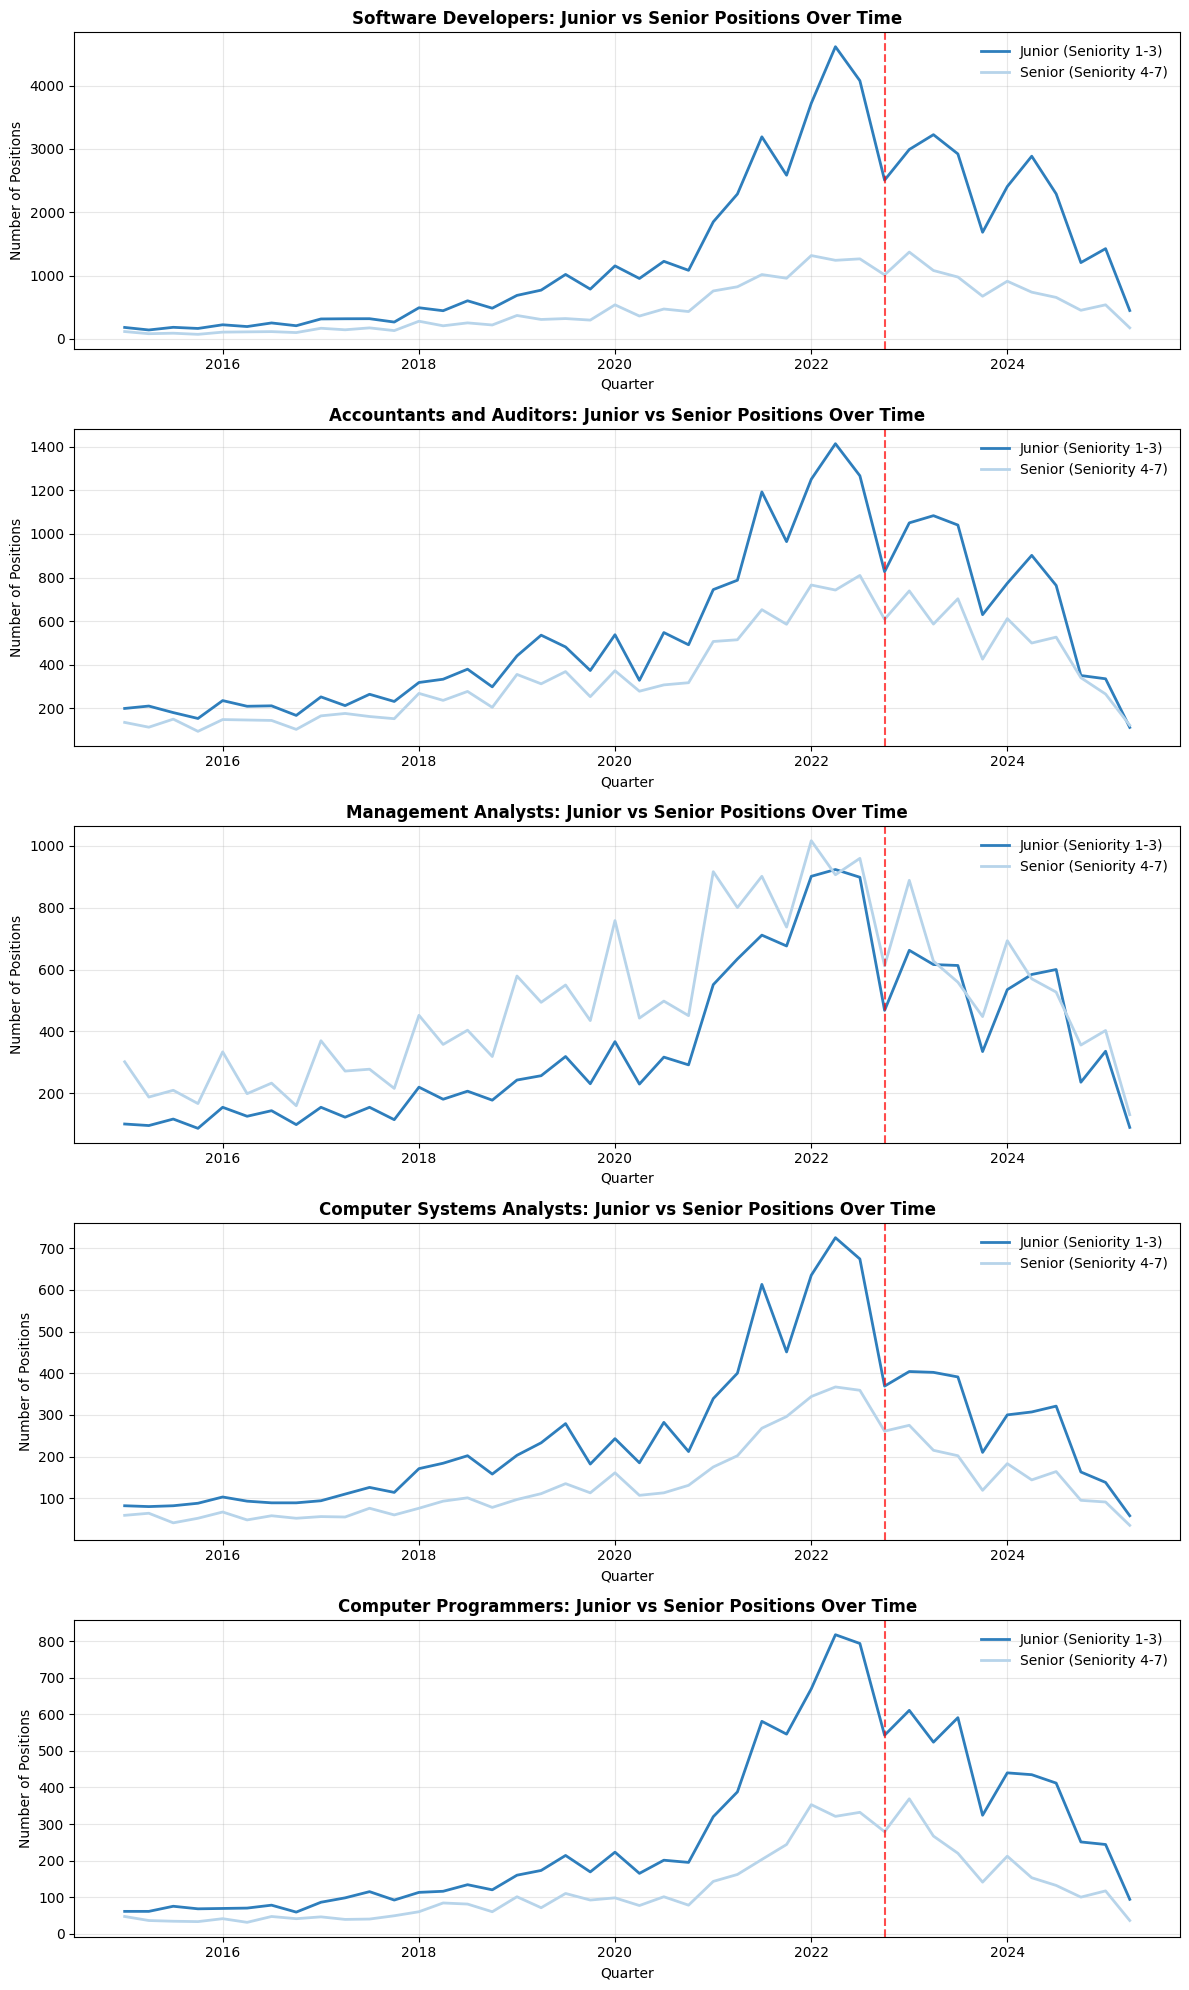


SUMMARY STATISTICS BY OCCUPATION AND LEVEL

Software Developers:
  Junior  : Pre-treatment avg =  1123.3, Post-treatment avg =  2181.6, Change =  +94.2%
  Senior  : Pre-treatment avg =   415.3, Post-treatment avg =   781.2, Change =  +88.1%

Accountants and Auditors:
  Junior  : Pre-treatment avg =   491.3, Post-treatment avg =   715.7, Change =  +45.7%
  Senior  : Pre-treatment avg =   317.4, Post-treatment avg =   493.9, Change =  +55.6%

Management Analysts:
  Junior  : Pre-treatment avg =   316.4, Post-treatment avg =   461.4, Change =  +45.8%
  Senior  : Pre-treatment avg =   480.8, Post-treatment avg =   528.5, Change =   +9.9%

Computer Systems Analysts:
  Junior  : Pre-treatment avg =   242.6, Post-treatment avg =   278.5, Change =  +14.8%
  Senior  : Pre-treatment avg =   129.5, Post-treatment avg =   162.2, Change =  +25.2%

Computer Programmers:
  Junior  : Pre-treatment avg =   226.8, Post-treatment avg =   406.3, Change =  +79.1%
  Senior  : Pre-treatment avg =   105.0, P

In [41]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap

# -----------------------------
# Paths
# -----------------------------
POS_DIR = r"C:\LocalOneDrive\Documents\Desktop\NUS\Y4S1\FYP\causal-impact-GenAI\data\Positions"
OCC_LEVEL_PATH = r"C:\LocalOneDrive\Documents\Desktop\NUS\Y4S1\FYP\causal-impact-GenAI\data\AI Exposure Scores\occ_level.csv"

TREAT_Q = pd.Period("2022Q4", freq="Q")
PANEL_START = pd.Timestamp("2015-01-01")

DATE_COL = "startdate"
SEN_COL = "seniority"

# Define occupations to analyze
# Map O*NET codes to readable names
OCCS_TO_ANALYZE = {
    "15-1252.00": "Software Developers",
    "13-2011.00": "Accountants and Auditors",
    "13-1111.00": "Management Analysts",
    "15-1211.00": "Computer Systems Analysts",
    "15-1251.00": "Computer Programmers",
}

# -----------------------------
# 1) Read all positions files
# -----------------------------
pos_files = sorted(glob.glob(os.path.join(POS_DIR, "*_positions.csv")))
if len(pos_files) == 0:
    raise FileNotFoundError(f"No *_positions.csv found in {POS_DIR}")

dfs = []
for f in pos_files:
    d = pd.read_csv(f)
    d["source_file"] = os.path.basename(f)
    dfs.append(d)

positions = pd.concat(dfs, ignore_index=True)

# -----------------------------
# 2) Cleaning + restrict to 2015 onwards
# -----------------------------
if DATE_COL not in positions.columns:
    raise KeyError(f"Expected date column '{DATE_COL}' not found in positions files.")
if SEN_COL not in positions.columns:
    raise KeyError(f"Expected seniority column '{SEN_COL}' not found in positions files.")
if "onet_code" not in positions.columns:
    raise KeyError(f"Expected 'onet_code' column not found in positions files.")

positions[DATE_COL] = pd.to_datetime(positions[DATE_COL], errors="coerce")
positions = positions[positions[DATE_COL].notna()].copy()
positions = positions[positions[DATE_COL] >= PANEL_START].copy()

positions[SEN_COL] = pd.to_numeric(positions[SEN_COL], errors="coerce")
positions = positions[positions[SEN_COL].between(1, 7, inclusive="both")].copy()
positions[SEN_COL] = positions[SEN_COL].astype(int)

positions["onet_code"] = positions["onet_code"].astype(str).str.strip()
positions["qtr"] = positions[DATE_COL].dt.to_period("Q")

# Create junior/senior indicator
positions["level"] = positions[SEN_COL].apply(lambda x: "Junior" if x <= 3 else "Senior")

# -----------------------------
# 3) Filter for selected occupations
# -----------------------------
positions = positions[positions["onet_code"].isin(OCCS_TO_ANALYZE.keys())].copy()
positions["occ_name"] = positions["onet_code"].map(OCCS_TO_ANALYZE)

print(f"Total positions after filtering: {len(positions)}")
print(f"Occupations found: {positions['occ_name'].unique()}")

# -----------------------------
# 4) Aggregate by quarter, occupation, and level
# -----------------------------
ts = (
    positions
    .groupby(["qtr", "occ_name", "level"], as_index=False)
    .size()
    .rename(columns={"size": "postings"})
)

# Create full grid
all_qtrs = pd.period_range(positions["qtr"].min(), positions["qtr"].max(), freq="Q")
all_occs = list(OCCS_TO_ANALYZE.values())
all_levels = ["Junior", "Senior"]

full = (
    pd.MultiIndex.from_product([all_qtrs, all_occs, all_levels], names=["qtr", "occ_name", "level"])
    .to_frame(index=False)
    .merge(ts, on=["qtr", "occ_name", "level"], how="left")
)

full["postings"] = full["postings"].fillna(0)
full["qtr_start"] = full["qtr"].dt.to_timestamp(how="start")

# -----------------------------
# 5) Plot separate charts for each occupation
# -----------------------------
treat_date = TREAT_Q.to_timestamp(how="start")

# Use single-hue colormap with different shades for junior/senior
cmap = get_cmap("Blues")
junior_color = cmap(0.7)  # Darker
senior_color = cmap(0.3)  # Lighter

# Get unique occupations that actually have data
occs_with_data = full[full["postings"] > 0]["occ_name"].unique()

n_occs = len(occs_with_data)
fig, axes = plt.subplots(n_occs, 1, figsize=(12, 4 * n_occs))

if n_occs == 1:
    axes = [axes]

for idx, occ in enumerate(occs_with_data):
    ax = axes[idx]
    occ_data = full[full["occ_name"] == occ]
    
    # Plot junior
    junior_data = occ_data[occ_data["level"] == "Junior"].sort_values("qtr_start")
    ax.plot(junior_data["qtr_start"], junior_data["postings"], 
            label="Junior (Seniority 1-3)", color=junior_color, linewidth=2)
    
    # Plot senior
    senior_data = occ_data[occ_data["level"] == "Senior"].sort_values("qtr_start")
    ax.plot(senior_data["qtr_start"], senior_data["postings"], 
            label="Senior (Seniority 4-7)", color=senior_color, linewidth=2)
    
    # Treatment line
    ax.axvline(treat_date, color="red", linestyle="--", linewidth=1.5, alpha=0.7)
    ax.text(treat_date, ax.get_ylim()[1] * 0.95, "", 
            rotation=90, va="top", ha="right", fontsize=9, color="red")
    
    ax.set_title(f"{occ}: Junior vs Senior Positions Over Time", fontsize=12, fontweight="bold")
    ax.set_xlabel("Quarter")
    ax.set_ylabel("Number of Positions")
    ax.legend(frameon=False)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# -----------------------------
# 6) Print summary statistics
# -----------------------------
print("\n" + "="*80)
print("SUMMARY STATISTICS BY OCCUPATION AND LEVEL")
print("="*80)

for occ in occs_with_data:
    print(f"\n{occ}:")
    occ_data = full[full["occ_name"] == occ]
    
    # Pre and post treatment
    pre_data = occ_data[occ_data["qtr"] < TREAT_Q]
    post_data = occ_data[occ_data["qtr"] >= TREAT_Q]
    
    for level in ["Junior", "Senior"]:
        pre_avg = pre_data[pre_data["level"] == level]["postings"].mean()
        post_avg = post_data[post_data["level"] == level]["postings"].mean()
        pct_change = ((post_avg - pre_avg) / pre_avg * 100) if pre_avg > 0 else 0
        
        print(f"  {level:8s}: Pre-treatment avg = {pre_avg:7.1f}, Post-treatment avg = {post_avg:7.1f}, Change = {pct_change:+6.1f}%")

WITHOUT INTERNSHIPS

C:\Users\teomi\AppData\Local\Temp\ipykernel_38004\989040355.py:144: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_intern = positions["title_raw"].fillna("").str.contains(intern_pat, case=False, regex=True)


After removing internship titles: 2510959 rows remain
Total positions after occupation filter: 177371
Occupations found: ['Software Developers' 'Accountants and Auditors' 'Management Analysts'
 'Computer Programmers' 'Computer Systems Analysts']


C:\Users\teomi\AppData\Local\Temp\ipykernel_38004\989040355.py:185: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("Blues")


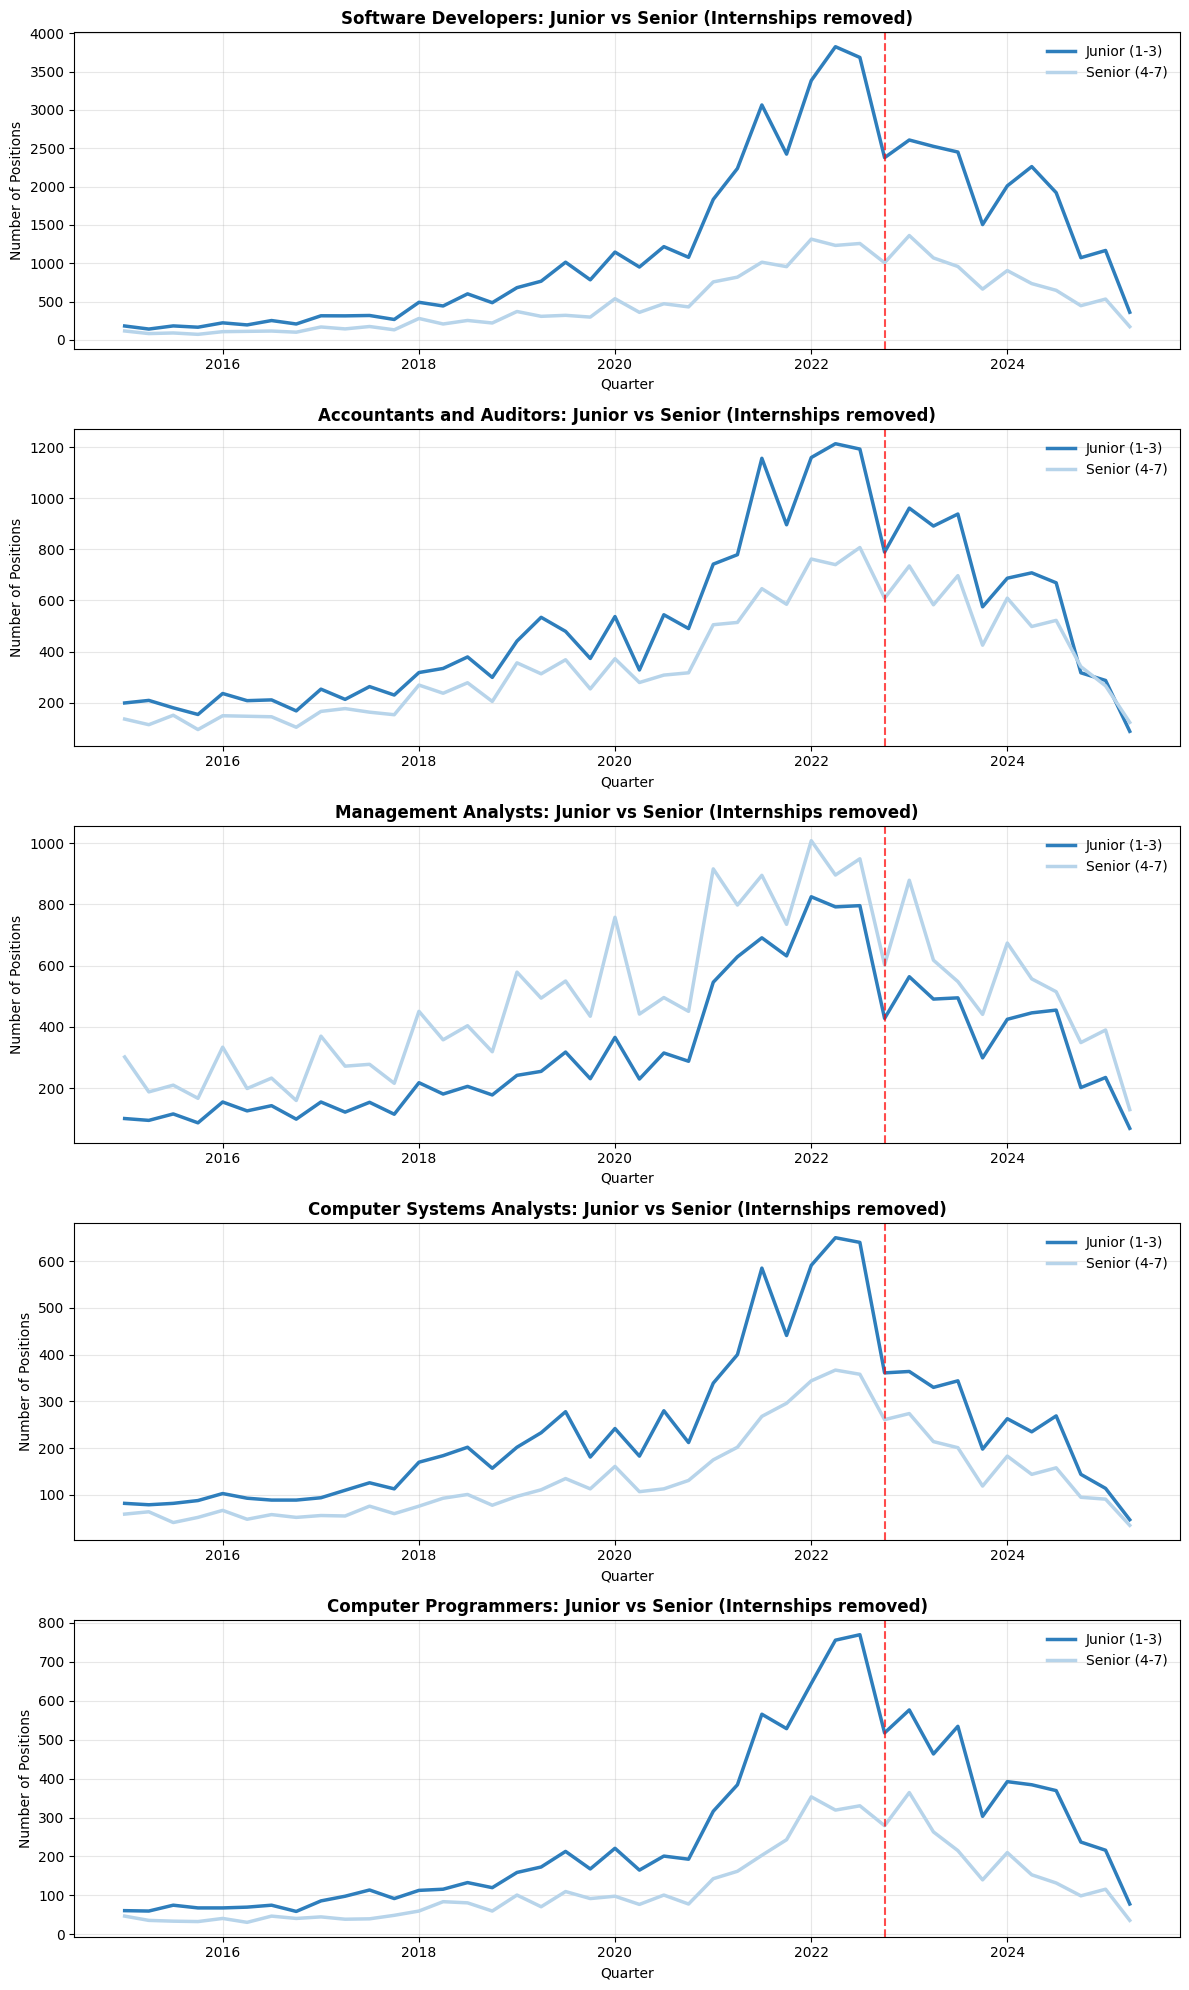


SUMMARY STATISTICS BY OCCUPATION AND LEVEL (Internships removed)

Software Developers:
  Junior  : Pre =  1060.6, Post =  1841.8, Change =  +73.7%
  Senior  : Pre =   414.0, Post =   772.7, Change =  +86.6%

Accountants and Auditors:
  Junior  : Pre =   474.7, Post =   628.2, Change =  +32.3%
  Senior  : Pre =   316.6, Post =   491.6, Change =  +55.3%

Management Analysts:
  Junior  : Pre =   303.5, Post =   373.5, Change =  +23.1%
  Senior  : Pre =   479.5, Post =   518.5, Change =   +8.2%

Computer Systems Analysts:
  Junior  : Pre =   236.1, Post =   242.6, Change =   +2.8%
  Senior  : Pre =   129.5, Post =   161.4, Change =  +24.6%

Computer Programmers:
  Junior  : Pre =   221.4, Post =   369.9, Change =  +67.1%
  Senior  : Pre =   104.8, Post =   182.5, Change =  +74.1%


In [43]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap

# -----------------------------
# Paths
# -----------------------------
POS_DIR = r"C:\LocalOneDrive\Documents\Desktop\NUS\Y4S1\FYP\causal-impact-GenAI\data\Positions"
TITLES_DIR = r"C:\LocalOneDrive\Documents\Desktop\NUS\Y4S1\FYP\causal-impact-GenAI\data\Positions\Titles"
TITLES_OLD = os.path.join(TITLES_DIR, "titles.csv")
TITLES_2025 = os.path.join(TITLES_DIR, "titles_2025.csv")

TREAT_Q = pd.Period("2022Q4", freq="Q")
PANEL_START = pd.Timestamp("2015-01-01")
DATE_COL = "startdate"
SEN_COL = "seniority"

# Occupations to analyze
OCCS_TO_ANALYZE = {
    "15-1252.00": "Software Developers",
    "13-2011.00": "Accountants and Auditors",
    "13-1111.00": "Management Analysts",
    "15-1211.00": "Computer Systems Analysts",
    "15-1251.00": "Computer Programmers",
}

# -----------------------------
# 0) Read titles files, concat, de-dupe to 1 row per user_id
# -----------------------------
def read_titles_robust(path):
    # Increase allowed CSV field size (prevents "buffer overflow" for long strings)
    try:
        csv.field_size_limit(min(sys.maxsize, 2_000_000_000))
    except Exception:
        pass

    # Try a few common encodings; fall back to tolerant read
    encodings_to_try = ["utf-8", "utf-8-sig", "cp1252", "latin1"]

    last_err = None
    for enc in encodings_to_try:
        try:
            return pd.read_csv(
                path,
                engine="python",                 # more tolerant than C engine
                encoding=enc,
                encoding_errors="replace",
                on_bad_lines="skip",             # skip malformed rows
                quotechar='"',
                escapechar="\\",
            )
        except Exception as e:
            last_err = e

    raise last_err

# -----------------------------
# 0) Read titles files, concat, de-dupe to 1 row per user_id
# -----------------------------
titles_parts = []
for fp in [TITLES_OLD, TITLES_2025]:
    if os.path.exists(fp):
        t = read_titles_robust(fp)
        t["source_titles"] = os.path.basename(fp)
        titles_parts.append(t)
    else:
        print(f"[WARN] Missing titles file: {fp}")

if len(titles_parts) == 0:
    raise FileNotFoundError("No titles.csv / titles_2025.csv found in Titles folder.")

titles = pd.concat(titles_parts, ignore_index=True)

# Keep only what we need (adjust if your titles file uses a different column name)
if "user_id" not in titles.columns:
    raise KeyError("Titles files must contain 'user_id'")

# Some exports name it differently; if so, uncomment and fix:
# titles = titles.rename(columns={"userid": "user_id", "title": "title_raw"})

if "title_raw" not in titles.columns:
    raise KeyError("Titles files must contain 'title_raw'")

titles["user_id"] = pd.to_numeric(titles["user_id"], errors="coerce")
titles = titles.dropna(subset=["user_id"]).copy()
titles["user_id"] = titles["user_id"].astype("int64")
titles["title_raw"] = titles["title_raw"].astype(str)

# De-dupe to 1 row per user_id: keep the longest title (simple heuristic)
titles["title_len"] = titles["title_raw"].str.len()
titles = titles.sort_values(["user_id", "title_len"], ascending=[True, False]).drop_duplicates(subset=["user_id"])
titles = titles.drop(columns=["title_len"])

# -----------------------------
# 1) Read all positions files
# -----------------------------
pos_files = sorted(glob.glob(os.path.join(POS_DIR, "*_positions.csv")))
if len(pos_files) == 0:
    raise FileNotFoundError(f"No *_positions.csv found in {POS_DIR}")

dfs = []
for f in pos_files:
    d = pd.read_csv(f)
    d["source_file"] = os.path.basename(f)
    dfs.append(d)

positions = pd.concat(dfs, ignore_index=True)

# -----------------------------
# 2) Cleaning + restrict to 2015 onwards
# -----------------------------
for col in [DATE_COL, SEN_COL, "onet_code", "user_id"]:
    if col not in positions.columns:
        raise KeyError(f"Expected '{col}' column not found in positions files.")

positions["user_id"] = pd.to_numeric(positions["user_id"], errors="coerce")
positions = positions.dropna(subset=["user_id"]).copy()
positions["user_id"] = positions["user_id"].astype("int64")

positions[DATE_COL] = pd.to_datetime(positions[DATE_COL], errors="coerce")
positions = positions[positions[DATE_COL].notna()].copy()
positions = positions[positions[DATE_COL] >= PANEL_START].copy()

positions[SEN_COL] = pd.to_numeric(positions[SEN_COL], errors="coerce")
positions = positions[positions[SEN_COL].between(1, 7, inclusive="both")].copy()
positions[SEN_COL] = positions[SEN_COL].astype(int)

positions["onet_code"] = positions["onet_code"].astype(str).str.strip()
positions["qtr"] = positions[DATE_COL].dt.to_period("Q")

# Junior vs Senior
positions["level"] = np.where(positions[SEN_COL] <= 3, "Junior", "Senior")

# -----------------------------
# 3) Merge titles on user_id + remove internships
# -----------------------------
positions = positions.merge(titles[["user_id", "title_raw"]], on="user_id", how="left")

# Drop rows where title indicates internship
intern_pat = r"\b(intern|internship)\b"
mask_intern = positions["title_raw"].fillna("").str.contains(intern_pat, case=False, regex=True)
positions = positions[~mask_intern].copy()

print(f"After removing internship titles: {len(positions)} rows remain")

# -----------------------------
# 4) Filter for selected occupations
# -----------------------------
positions = positions[positions["onet_code"].isin(OCCS_TO_ANALYZE.keys())].copy()
positions["occ_name"] = positions["onet_code"].map(OCCS_TO_ANALYZE)

print(f"Total positions after occupation filter: {len(positions)}")
print(f"Occupations found: {positions['occ_name'].unique()}")

# -----------------------------
# 5) Aggregate by quarter, occupation, and level
# -----------------------------
ts = (
    positions
    .groupby(["qtr", "occ_name", "level"], as_index=False)
    .size()
    .rename(columns={"size": "postings"})
)

all_qtrs = pd.period_range(ts["qtr"].min(), ts["qtr"].max(), freq="Q")
all_occs = list(OCCS_TO_ANALYZE.values())
all_levels = ["Junior", "Senior"]

full = (
    pd.MultiIndex.from_product([all_qtrs, all_occs, all_levels], names=["qtr", "occ_name", "level"])
    .to_frame(index=False)
    .merge(ts, on=["qtr", "occ_name", "level"], how="left")
)

full["postings"] = full["postings"].fillna(0)
full["qtr_start"] = full["qtr"].dt.to_timestamp(how="start")

# -----------------------------
# 6) Plot separate charts for each occupation
# -----------------------------
treat_date = TREAT_Q.to_timestamp(how="start")
cmap = get_cmap("Blues")
junior_color = cmap(0.7)
senior_color = cmap(0.3)

occs_with_data = full[full["postings"] > 0]["occ_name"].unique()
n_occs = len(occs_with_data)

fig, axes = plt.subplots(n_occs, 1, figsize=(12, 4 * n_occs))
if n_occs == 1:
    axes = [axes]

for idx, occ in enumerate(occs_with_data):
    ax = axes[idx]
    occ_data = full[full["occ_name"] == occ]

    d_j = occ_data[occ_data["level"] == "Junior"].sort_values("qtr_start")
    d_s = occ_data[occ_data["level"] == "Senior"].sort_values("qtr_start")

    ax.plot(d_j["qtr_start"], d_j["postings"], label="Junior (1-3)", color=junior_color, linewidth=2.5)
    ax.plot(d_s["qtr_start"], d_s["postings"], label="Senior (4-7)", color=senior_color, linewidth=2.5)

    ax.axvline(treat_date, color="red", linestyle="--", linewidth=1.5, alpha=0.7)
    ax.set_title(f"{occ}: Junior vs Senior (Internships removed)", fontsize=12, fontweight="bold")
    ax.set_xlabel("Quarter")
    ax.set_ylabel("Number of Positions")
    ax.legend(frameon=False)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# -----------------------------
# 7) Print summary statistics
# -----------------------------
print("\n" + "="*80)
print("SUMMARY STATISTICS BY OCCUPATION AND LEVEL (Internships removed)")
print("="*80)

for occ in occs_with_data:
    print(f"\n{occ}:")
    occ_data = full[full["occ_name"] == occ]

    pre_data = occ_data[occ_data["qtr"] < TREAT_Q]
    post_data = occ_data[occ_data["qtr"] >= TREAT_Q]

    for level in ["Junior", "Senior"]:
        pre_avg = pre_data[pre_data["level"] == level]["postings"].mean()
        post_avg = post_data[post_data["level"] == level]["postings"].mean()
        pct_change = ((post_avg - pre_avg) / pre_avg * 100) if pre_avg > 0 else 0
        print(f"  {level:8s}: Pre = {pre_avg:7.1f}, Post = {post_avg:7.1f}, Change = {pct_change:+6.1f}%")
